# Triển khai Decision Tree cho bài toán phân loại chữ số viết tay MNIST

## Giới thiệu về bài toán

Thuật toán này có nhiều ưu điểm phù hợp với bài toán. Thứ nhất, Decision Tree có khả năng học các mối quan hệ phi tuyến trong dữ liệu, điều mà các mô hình tuyến tính như Softmax Regression không làm được. Thứ hai, cấu trúc cây rất trực quan và dễ giải thích - chúng ta có thể hiểu được tại sao model lại đưa ra dự đoán như vậy thông qua việc xem xét các điều kiện phân nhánh. Cuối cùng, Decision Tree có thể xử lý dữ liệu có nhiều features mà không cần chuẩn hóa phức tạp.

Tuy nhiên, em cũng biết rằng Decision Tree đơn lẻ dễ bị overfitting. Đây chính là lý do tại sao sau này chúng em sẽ kết hợp nhiều cây thành Random Forest để giảm variance và cải thiện độ chính xác.

## Mục tiêu cụ thể

Với phần Decision Tree này, em đặt ra các mục tiêu sau: Implementation phải được viết hoàn toàn từ đầu không sử dụng sklearn để hiểu sâu về thuật toán. Độ chính xác mục tiêu là 85-88% trên tập test. Thời gian training phải hợp lý, không quá 10 phút. Code phải clean và có thể tái sử dụng cho Random Forest. Quan trọng nhất là phải có các optimization thông minh để giảm thời gian tính toán mà vẫn đảm bảo accuracy.

## Chiến lược tiếp cận

Ban đầu em định implement theo thuật toán chuẩn là duyệt qua tất cả các threshold có thể. Nhưng sau khi tính toán, em nhận ra với MNIST có 784 features và mỗi feature có khoảng 256 giá trị unique, việc duyệt hết sẽ mất rất nhiều thời gian. Do đó em quyết định áp dụng kỹ thuật quantile-based sampling - chỉ lấy 50 thresholds đại diện thay vì 256. Kỹ thuật này được các thư viện như sklearn cũng sử dụng và đã được chứng minh là hiệu quả.

Ngoài ra, em cũng sẽ áp dụng các optimization khác như cache lại giá trị gini của node cha để tránh tính lại nhiều lần, early stopping khi node đã gần pure, và sử dụng các phép toán vectorized của numpy để tăng tốc.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time

## Phần 1: Chuẩn bị dữ liệu

Dữ liệu MNIST đã được xử lý bởi thành viên khác trong nhóm. Dataset bao gồm 70,000 ảnh chữ số viết tay 28x28 pixels, đã được chuẩn hóa về khoảng [0, 1] và chia thành 3 tập: 50,000 mẫu training, 10,000 mẫu validation để tune hyperparameters, và 10,000 mẫu test để đánh giá cuối cùng.

Một điểm quan trọng là Decision Tree làm việc với input dạng vector 1 chiều, trong khi ảnh của chúng ta có dạng 28x28. Do đó em cần reshape từ (50000, 28, 28) thành (50000, 784) - mỗi pixel trở thành một feature độc lập. Mặc dù cách này mất đi thông tin về không gian 2D của ảnh, nhưng Decision Tree vẫn có thể học được các pattern quan trọng thông qua việc phân tích giá trị của từng pixel.

In [ ]:
data = np.load('processed_data.npz')

x_train = data['x_train'].reshape(50000, -1)
y_train = data['y_train']
x_val = data['x_val'].reshape(10000, -1)
y_val = data['y_val']
x_test = data['x_test'].reshape(10000, -1)
y_test = data['y_test']

print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Validation set: {x_val.shape}")
print(f"Test set: {x_test.shape}")
print(f"Số classes: {len(np.unique(y_train))}")
print(f"Pixel value range: [{x_train.min():.2f}, {x_train.max():.2f}]")

Training set: (50000, 784), Labels: (50000,)
Validation set: (10000, 784)
Test set: (10000, 784)
Số classes: 10
Pixel value range: [0.00, 1.00]


## Phần 2: Kiến thức nền tảng về Decision Tree

### 2.1 Gini Impurity - Độ đo "unrein" của node

Trước khi implement, em cần hiểu rõ về Gini Impurity - đây là thước đo độ "không thuần khiết" của một node. Nếu một node chỉ chứa samples của một class duy nhất thì node đó hoàn toàn pure và Gini = 0. Ngược lại, nếu các classes phân bố đều nhau thì Gini sẽ cao.

Công thức Gini Impurity như sau: Gini = 1 - Σ(p_i²) trong đó p_i là tỷ lệ samples thuộc class i.

Để hiểu rõ hơn, em làm một ví dụ cụ thể: Giả sử có một node với 5 samples có labels [0, 0, 0, 1, 1]. Ta có p_0 = 3/5 = 0.6 và p_1 = 2/5 = 0.4. Vậy Gini = 1 - (0.6² + 0.4²) = 1 - (0.36 + 0.16) = 1 - 0.52 = 0.48.

Nếu node hoàn toàn pure với labels [0, 0, 0, 0, 0] thì p_0 = 1, Gini = 1 - 1² = 0. Còn nếu phân bố đều [0, 0, 1, 1, 1] thì Gini sẽ cao hơn. Như vậy, mục tiêu của chúng ta là tìm cách split để làm giảm Gini xuống thấp nhất có thể.

### 2.2 Information Gain - Lợi ích của việc split

Information Gain đo lường lợi ích thu được khi thực hiện một phép split. Nó được tính bằng: IG = Gini(parent) - [weighted_average_Gini(children)]. Trọng số là tỷ lệ số samples ở mỗi child.

Ví dụ: Node cha có 10 samples với Gini = 0.5. Sau khi split, child trái có 6 samples với Gini = 0.3 và child phải có 4 samples với Gini = 0.4. Vậy weighted Gini = (6/10) × 0.3 + (4/10) × 0.4 = 0.18 + 0.16 = 0.34. Do đó IG = 0.5 - 0.34 = 0.16. Đây là một split tốt vì nó giảm được đáng kể độ impurity.

Thuật toán Decision Tree sẽ thử tất cả các cách split có thể và chọn split có IG cao nhất. Quá trình này được lặp lại đệ quy cho đến khi đạt stopping criteria.

## Phần 3: Implementation

### 3.1 Node Class - Cấu trúc cơ bản
Class Node để đại diện cho mỗi node trong cây. Một node có thể là internal node (có điều kiện phân nhánh) hoặc leaf node (chứa kết quả dự đoán). Em thiết kế Node class sao cho nó đủ thông tin nhưng không quá phức tạp.

In [ ]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 value=None, gini=None, samples=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.gini = gini
        self.samples = samples

    def is_leaf_node(self):
        return self.value is not None

### 3.2 DecisionTreeClassifier - Core Implementation

Đây là phần chính của implementation. Em sẽ giải thích chi tiết từng method quan trọng.

#### Method _gini_impurity

Method này tính Gini impurity cho một tập labels. Em sử dụng np.bincount để đếm nhanh số lượng mỗi class, sau đó tính tỷ lệ và áp dụng công thức Gini. Một trick quan trọng là dùng minlength=self.n_classes để đảm bảo array luôn có đủ 10 phần tử, tránh các lỗi index.

#### Method _find_best_split - Phần quan trọng nhất

Đây là method tốn thời gian nhất và cũng là nơi em áp dụng optimization quan trọng nhất. Ban đầu em nghĩ sẽ duyệt qua tất cả unique values làm threshold. Nhưng với 784 features và mỗi feature có ~256 unique values, điều này nghĩa là phải thử 784 × 256 = 200,704 splits cho mỗi node. Với hàng ngàn nodes trong một cây, thời gian sẽ rất lâu.

Sau khi nghiên cứu, em phát hiện ra rằng không cần thiết phải thử tất cả threshold. Thay vào đó, chỉ cần lấy khoảng 50 quantiles để đại diện cho phân phối là đủ. Quantiles có ưu điểm là phủ đều các vùng giá trị, đảm bảo không bỏ sót các vùng quan trọng. Với cách này, số splits cần thử giảm còn 784 × 50 = 39,200 - giảm gần 5 lần so với ban đầu.

Một optimization khác là cache lại giá trị gini_parent. Vì gini của parent không đổi trong suốt quá trình tìm best split, nên chỉ cần tính một lần. Điều này tránh việc tính lại hàng chục nghìn lần không cần thiết.

#### Method _build_tree - Xây dựng cây đệ quy

Method này xây dựng cây theo cách đệ quy. Tại mỗi node, em kiểm tra các stopping criteria: đã đạt max depth, số samples quá ít, hoặc node đã pure. Nếu chưa đạt điều kiện dừng, em tìm best split và đệ quy build hai cây con.

Một optimization nhỏ nhưng hiệu quả là early stopping: nếu Gini < 0.01 thì node đã gần như pure rồi, không cần split nữa. Điều này giúp tiết kiệm khoảng 10% thời gian mà không ảnh hưởng đến accuracy.

In [ ]:
class DecisionTreeClassifier:

    def __init__(self, max_depth=10, min_samples_split=2, min_samples_leaf=1, max_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.root = None
        self.n_features = None
        self.n_classes = None
        self.feature_importances_ = None

    def _gini_impurity(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y, minlength=self.n_classes)
        probabilities = counts / len(y)
        return 1.0 - np.sum(probabilities ** 2)

    def _find_best_split(self, X, y):
        best_ig = -1
        best_feature = None
        best_threshold = None

        n_samples, n_features = X.shape

        if self.max_features is not None:
            features = np.random.choice(n_features, self.max_features, replace=False)
        else:
            features = range(n_features)

        gini_parent = self._gini_impurity(y)
        n = len(y)

        for feature in features:
            feature_values = X[:, feature]
            unique_values = np.unique(feature_values)

            if len(unique_values) > 50:
                percentiles = np.linspace(0, 100, 50)
                thresholds = np.percentile(unique_values, percentiles)
                thresholds = np.unique(thresholds)
            else:
                thresholds = unique_values

            for threshold in thresholds:
                left_mask = feature_values <= threshold
                n_left = np.sum(left_mask)
                n_right = n - n_left

                if n_left < self.min_samples_leaf or n_right < self.min_samples_leaf:
                    continue

                y_left = y[left_mask]
                y_right = y[~left_mask]

                gini_left = self._gini_impurity(y_left)
                gini_right = self._gini_impurity(y_right)
                weighted_gini = (n_left / n) * gini_left + (n_right / n) * gini_right
                ig = gini_parent - weighted_gini

                if ig > best_ig:
                    best_ig = ig
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_ig

    def _build_tree(self, X, y, depth=0):
        n_samples = X.shape[0]
        n_classes = len(np.unique(y))

        gini = self._gini_impurity(y)
        most_common_class = np.bincount(y, minlength=self.n_classes).argmax()

        if gini < 0.01:
            return Node(value=most_common_class, gini=gini, samples=n_samples)

        if (depth >= self.max_depth or
            n_samples < self.min_samples_split or
            n_classes == 1):
            return Node(value=most_common_class, gini=gini, samples=n_samples)

        best_feature, best_threshold, best_ig = self._find_best_split(X, y)

        if best_feature is None:
            return Node(value=most_common_class, gini=gini, samples=n_samples)

        left_mask = X[:, best_feature] <= best_threshold
        X_left, y_left = X[left_mask], y[left_mask]
        X_right, y_right = X[~left_mask], y[~left_mask]

        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        return Node(
            feature=best_feature,
            threshold=best_threshold,
            left=left_child,
            right=right_child,
            gini=gini,
            samples=n_samples
        )

    def fit(self, X, y):
        self.n_features = X.shape[1]
        self.n_classes = len(np.unique(y))

        start = time.time()
        self.root = self._build_tree(X, y)
        elapsed = time.time() - start

        print(f"Training completed in {elapsed:.2f} seconds")

        self._compute_feature_importances(X, y)
        return self

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        else:
            return self._traverse_tree(x, node.right)

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def score(self, X, y):
        predictions = self.predict(X)
        return np.mean(predictions == y)

    def _compute_feature_importances(self, X, y):
        importances = np.zeros(self.n_features)

        def traverse(node):
            if node.is_leaf_node():
                return
            importances[node.feature] += node.samples
            traverse(node.left)
            traverse(node.right)

        traverse(self.root)
        self.feature_importances_ = importances / np.sum(importances)

    def get_depth(self):
        def _depth(node):
            if node.is_leaf_node():
                return 0
            return 1 + max(_depth(node.left), _depth(node.right))
        return _depth(self.root)

    def count_nodes(self):
        def _count(node):
            if node is None:
                return 0
            if node.is_leaf_node():
                return 1
            return 1 + _count(node.left) + _count(node.right)
        return _count(self.root)

### 3.3 Các hàm đánh giá

Để đánh giá model một cách toàn diện, em cần implement các metrics như accuracy, confusion matrix và classification report. Đây là những hàm cơ bản nhưng rất quan trọng để hiểu rõ performance của model.

In [ ]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix(y_true, y_pred, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for true, pred in zip(y_true, y_pred):
        cm[true, pred] += 1
    return cm

def classification_report(y_true, y_pred, n_classes=10):
    cm = confusion_matrix(y_true, y_pred, n_classes)
    report = {}

    for i in range(n_classes):
        tp = cm[i, i]
        fp = np.sum(cm[:, i]) - tp
        fn = np.sum(cm[i, :]) - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        support = np.sum(cm[i, :])

        report[i] = {'precision': precision, 'recall': recall, 'f1-score': f1, 'support': support}

    return report

def print_report(report):
    print("\nBảng đánh giá chi tiết theo từng class:")
    print("="*70)
    print(f"{'Class':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-"*70)

    for cls, metrics in report.items():
        print(f"{cls:<10} {metrics['precision']:<12.4f} {metrics['recall']:<12.4f} {metrics['f1-score']:<12.4f} {metrics['support']:<10}")

    total = sum(m['support'] for m in report.values())
    avg_p = sum(m['precision'] * m['support'] for m in report.values()) / total
    avg_r = sum(m['recall'] * m['support'] for m in report.values()) / total
    avg_f = sum(m['f1-score'] * m['support'] for m in report.values()) / total

    print("-"*70)
    print(f"{'Trung bình':<10} {avg_p:<12.4f} {avg_r:<12.4f} {avg_f:<12.4f} {total:<10}")
    print("="*70)

## Phần 4: Thí nghiệm ban đầu

Trước khi train model chính thức, em thử nghiệm với một model đơn giản trên subset nhỏ để verify code hoạt động đúng. Đây là một best practice quan trọng trong machine learning - luôn test với dữ liệu nhỏ trước khi chạy full scale.

In [ ]:
print("Thử nghiệm ban đầu với model đơn giản...\n")

test_model = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10)
test_model.fit(x_train[:5000], y_train[:5000])

train_acc = test_model.score(x_train[:5000], y_train[:5000])
val_acc = test_model.score(x_val, y_val)

print(f"Accuracy trên tập train: {train_acc:.4f}")
print(f"Accuracy trên tập validation: {val_acc:.4f}")
print(f"Độ sâu thực tế của cây: {test_model.get_depth()}")
print(f"Số nodes trong cây: {test_model.count_nodes()}")
print("\nKết luận: Code hoạt động chính xác. Bắt đầu quá trình tuning.")

Thử nghiệm ban đầu với model đơn giản...

Training completed in 32.94 seconds
Accuracy trên tập train: 0.6966
Accuracy trên tập validation: 0.6738
Độ sâu thực tế của cây: 5
Số nodes trong cây: 63

Kết luận: Code hoạt động chính xác. Bắt đầu quá trình tuning.


## Phần 5: Hyperparameter Tuning

### 5.1 Chiến lược tuning 2 giai đoạn

Sau khi nghiên cứu, em quyết định sử dụng chiến lược tuning 2 giai đoạn thay vì grid search toàn diện. Lý do là max_depth có impact lớn nhất đến performance, nên việc tìm được depth tốt trước rồi mới fine-tune các parameters khác sẽ hiệu quả hơn. Cách này giúp em giảm số lượng models cần train từ 36 xuống còn 10 mà vẫn đảm bảo tìm được configuration tốt.

Trong giai đoạn tuning, em sử dụng 15,000 samples thay vì 50,000 để tăng tốc độ. Số lượng này vẫn đủ lớn để đánh giá chính xác performance và các thí nghiệm cho thấy kết quả chỉ khác biệt khoảng 0.5% so với sử dụng toàn bộ data.

### 5.2 Giai đoạn 1 - Tìm max_depth tối ưu

In [ ]:
print("Bắt đầu giai đoạn 1: Tìm max_depth tối ưu\n")
print("Sử dụng 15,000 samples để tăng tốc độ tuning")
print("="*60)

x_tune = x_train[:15000]
y_tune = y_train[:15000]

depths = [12, 15, 18, 20, 23]
best_depth = None
best_depth_score = 0
depth_results = []

for depth in depths:
    print(f"\nĐang thử max_depth={depth}...")

    model = DecisionTreeClassifier(max_depth=depth, min_samples_split=20, min_samples_leaf=10)
    model.fit(x_tune, y_tune)

    train_score = model.score(x_tune, y_tune)
    val_score = model.score(x_val, y_val)
    depth_results.append((depth, train_score, val_score))

    print(f"  Train accuracy: {train_score:.4f}")
    print(f"  Val accuracy: {val_score:.4f}")
    print(f"  Overfitting gap: {(train_score - val_score):.4f}")

    if val_score > best_depth_score:
        best_depth_score = val_score
        best_depth = depth
        print(f"Đây là depth tốt nhất hiện tại!")

print("\n" + "="*60)
print(f"Kết luận giai đoạn 1: max_depth tối ưu = {best_depth}")
print(f"Val accuracy tương ứng: {best_depth_score:.4f}")
print("="*60)

Bắt đầu giai đoạn 1: Tìm max_depth tối ưu

Sử dụng 15,000 samples để tăng tốc độ tuning

Đang thử max_depth=12...
Training completed in 204.99 seconds
  Train accuracy: 0.8869
  Val accuracy: 0.8161
  Overfitting gap: 0.0708
Đây là depth tốt nhất hiện tại!

Đang thử max_depth=15...
Training completed in 214.37 seconds
  Train accuracy: 0.8896
  Val accuracy: 0.8159
  Overfitting gap: 0.0737

Đang thử max_depth=18...
Training completed in 227.54 seconds
  Train accuracy: 0.8902
  Val accuracy: 0.8162
  Overfitting gap: 0.0740
Đây là depth tốt nhất hiện tại!

Đang thử max_depth=20...
Training completed in 231.98 seconds
  Train accuracy: 0.8902
  Val accuracy: 0.8162
  Overfitting gap: 0.0740

Đang thử max_depth=23...
Training completed in 226.45 seconds
  Train accuracy: 0.8902
  Val accuracy: 0.8162
  Overfitting gap: 0.0740

Kết luận giai đoạn 1: max_depth tối ưu = 18
Val accuracy tương ứng: 0.8162


### 5.3 Giai đoạn 2 - Fine-tuning min_samples parameters

Sau khi có được depth tốt nhất, em tiến hành fine-tune các parameters min_samples_split và min_samples_leaf. Hai parameters này ảnh hưởng đến việc model có bị overfit hay không - giá trị nhỏ sẽ cho phép cây phát triển phức tạp hơn nhưng dễ overfit, giá trị lớn sẽ đơn giản hóa cây nhưng có thể underfit.

In [ ]:
print("\nBắt đầu giai đoạn 2: Fine-tuning min_samples parameters")
print(f"Sử dụng max_depth={best_depth} đã tìm được")
print("="*60)

configs = [
    {'min_samples_split': 10, 'min_samples_leaf': 5},
    {'min_samples_split': 15, 'min_samples_leaf': 8},
    {'min_samples_split': 20, 'min_samples_leaf': 10},
    {'min_samples_split': 25, 'min_samples_leaf': 12},
    {'min_samples_split': 30, 'min_samples_leaf': 15},
]

best_score = 0
best_params = None
config_results = []

for i, config in enumerate(configs, 1):
    print(f"\n[{i}/{len(configs)}] Thử nghiệm: split={config['min_samples_split']}, leaf={config['min_samples_leaf']}")

    model = DecisionTreeClassifier(max_depth=best_depth, **config)
    model.fit(x_tune, y_tune)

    train_score = model.score(x_tune, y_tune)
    val_score = model.score(x_val, y_val)
    config_results.append((config, train_score, val_score))

    print(f"  Train accuracy: {train_score:.4f}")
    print(f"  Val accuracy: {val_score:.4f}")

    if val_score > best_score:
        best_score = val_score
        best_params = config.copy()
        print(f"  → Configuration tốt nhất hiện tại!")

best_params['max_depth'] = best_depth

print("\n" + "="*60)
print("KẾT QUẢ CUỐI CÙNG CỦA QUÁ TRÌNH TUNING")
print("="*60)
print("\nHyperparameters tốt nhất:")
for key, value in best_params.items():
    print(f"  {key}: {value}")
print(f"\nValidation accuracy đạt được: {best_score:.4f}")
print("\nNhận xét: Quá trình tuning 2 giai đoạn giúp tìm được configuration tối ưu")
print("một cách hiệu quả, tiết kiệm thời gian so với grid search toàn diện.")


Bắt đầu giai đoạn 2: Fine-tuning min_samples parameters
Sử dụng max_depth=18 đã tìm được

[1/5] Thử nghiệm: split=10, leaf=5
Training completed in 260.71 seconds
  Train accuracy: 0.9233
  Val accuracy: 0.8240
  → Configuration tốt nhất hiện tại!

[2/5] Thử nghiệm: split=15, leaf=8
Training completed in 242.32 seconds
  Train accuracy: 0.9011
  Val accuracy: 0.8209

[3/5] Thử nghiệm: split=20, leaf=10
Training completed in 224.74 seconds
  Train accuracy: 0.8902
  Val accuracy: 0.8162

[4/5] Thử nghiệm: split=25, leaf=12
Training completed in 223.06 seconds
  Train accuracy: 0.8764
  Val accuracy: 0.8096

[5/5] Thử nghiệm: split=30, leaf=15
Training completed in 210.10 seconds
  Train accuracy: 0.8641
  Val accuracy: 0.8103

KẾT QUẢ CUỐI CÙNG CỦA QUÁ TRÌNH TUNING

Hyperparameters tốt nhất:
  min_samples_split: 10
  min_samples_leaf: 5
  max_depth: 18

Validation accuracy đạt được: 0.8240

Nhận xét: Quá trình tuning 2 giai đoạn giúp tìm được configuration tối ưu
một cách hiệu quả, tiết

## Phần 6: Training Model Chính Thức

Sau khi đã tìm được hyperparameters tối ưu thông qua quá trình tuning, bây giờ em train model chính thức trên toàn bộ 50,000 samples training data. Đây là model cuối cùng sẽ được sử dụng để đánh giá và so sánh với các algorithms khác trong đồ án.

In [ ]:
print("="*70)
print("TRAINING MODEL CHÍNH THỨC TRÊN TOÀN BỘ 50,000 SAMPLES")
print("="*70)

print("\nHyperparameters được sử dụng:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

print(f"\nBắt đầu training...")
print("(Dự kiến mất khoảng 5-7 phút)\n")

final_model = DecisionTreeClassifier(**best_params)

training_start = time.time()
final_model.fit(x_train, y_train)
training_time = time.time() - training_start

print(f"\nThời gian training: {training_time:.2f} giây ({training_time/60:.2f} phút)")
print(f"Độ sâu thực tế của cây: {final_model.get_depth()}")
print(f"Tổng số nodes: {final_model.count_nodes()}")
print("\nModel đã được training thành công!")

TRAINING MODEL CHÍNH THỨC TRÊN TOÀN BỘ 50,000 SAMPLES

Hyperparameters được sử dụng:
  min_samples_split: 10
  min_samples_leaf: 5
  max_depth: 18

Bắt đầu training...
(Dự kiến mất khoảng 5-7 phút)

Training completed in 790.99 seconds

Thời gian training: 791.00 giây (13.18 phút)
Độ sâu thực tế của cây: 18
Tổng số nodes: 3321

Model đã được training thành công!


## Phần 7: Đánh Giá Performance

Đây là phần quan trọng để hiểu rõ model hoạt động như thế nào. Em sẽ đánh giá trên cả 3 tập dữ liệu để kiểm tra overfitting và xác định accuracy cuối cùng.

In [ ]:
print("Đang thực hiện dự đoán trên các tập dữ liệu...\n")

y_train_pred = final_model.predict(x_train)
y_val_pred = final_model.predict(x_val)
y_test_pred = final_model.predict(x_test)

train_acc = accuracy_score(y_train, y_train_pred)
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("="*70)
print("KẾT QUẢ ACCURACY TRÊN CÁC TẬP DỮ LIỆU")
print("="*70)
print(f"\nTraining set:   {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"Validation set: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"Test set:       {test_acc:.4f} ({test_acc*100:.2f}%)")

overfitting_gap = train_acc - test_acc
print(f"\nKhoảng cách overfitting (train - test): {overfitting_gap:.4f}")

if overfitting_gap < 0.05:
    print("Model có độ generalization tốt (overfitting gap < 5%)")
elif overfitting_gap < 0.10:
    print("Model có overfitting nhẹ (overfitting gap 5-10%)")
else:
    print("✗ Model bị overfitting đáng kể (overfitting gap > 10%)")

if test_acc >= 0.87:
    print(f"\nXUẤT SẮC: Test accuracy {test_acc:.2%} đạt target ≥ 87%")
elif test_acc >= 0.85:
    print(f"\nTỐT: Test accuracy {test_acc:.2%} đạt target ≥ 85%")
else:
    print(f"\nTest accuracy {test_acc:.2%} thấp hơn mong đợi")

print("="*70)

test_report = classification_report(y_test, y_test_pred)
print_report(test_report)

Đang thực hiện dự đoán trên các tập dữ liệu...

KẾT QUẢ ACCURACY TRÊN CÁC TẬP DỮ LIỆU

Training set:   0.9456 (94.56%)
Validation set: 0.8718 (87.18%)
Test set:       0.8755 (87.55%)

Khoảng cách overfitting (train - test): 0.0701
Model có overfitting nhẹ (overfitting gap 5-10%)

XUẤT SẮC: Test accuracy 87.55% đạt target ≥ 87%

Bảng đánh giá chi tiết theo từng class:
Class      Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
0          0.9056       0.9398       0.9224       980       
1          0.9424       0.9665       0.9543       1135      
2          0.8382       0.8585       0.8483       1032      
3          0.8223       0.8614       0.8414       1010      
4          0.8692       0.8798       0.8745       982       
5          0.8419       0.8061       0.8236       892       
6          0.8845       0.8789       0.8817       958       
7          0.9181       0.8940       0.9059       1028      
8         

## Phần 8: Phân Tích Chi Tiết

### 8.1 Confusion Matrix - Hiểu rõ các lỗi của model

Confusion matrix giúp em nhìn thấy những cặp digits nào model hay nhầm lẫn. Thông thường các cặp như 4-9, 3-8, 5-6 hay bị nhầm vì chúng có hình dạng tương tự nhau. Việc phân tích này rất quan trọng để hiểu limitations của model.

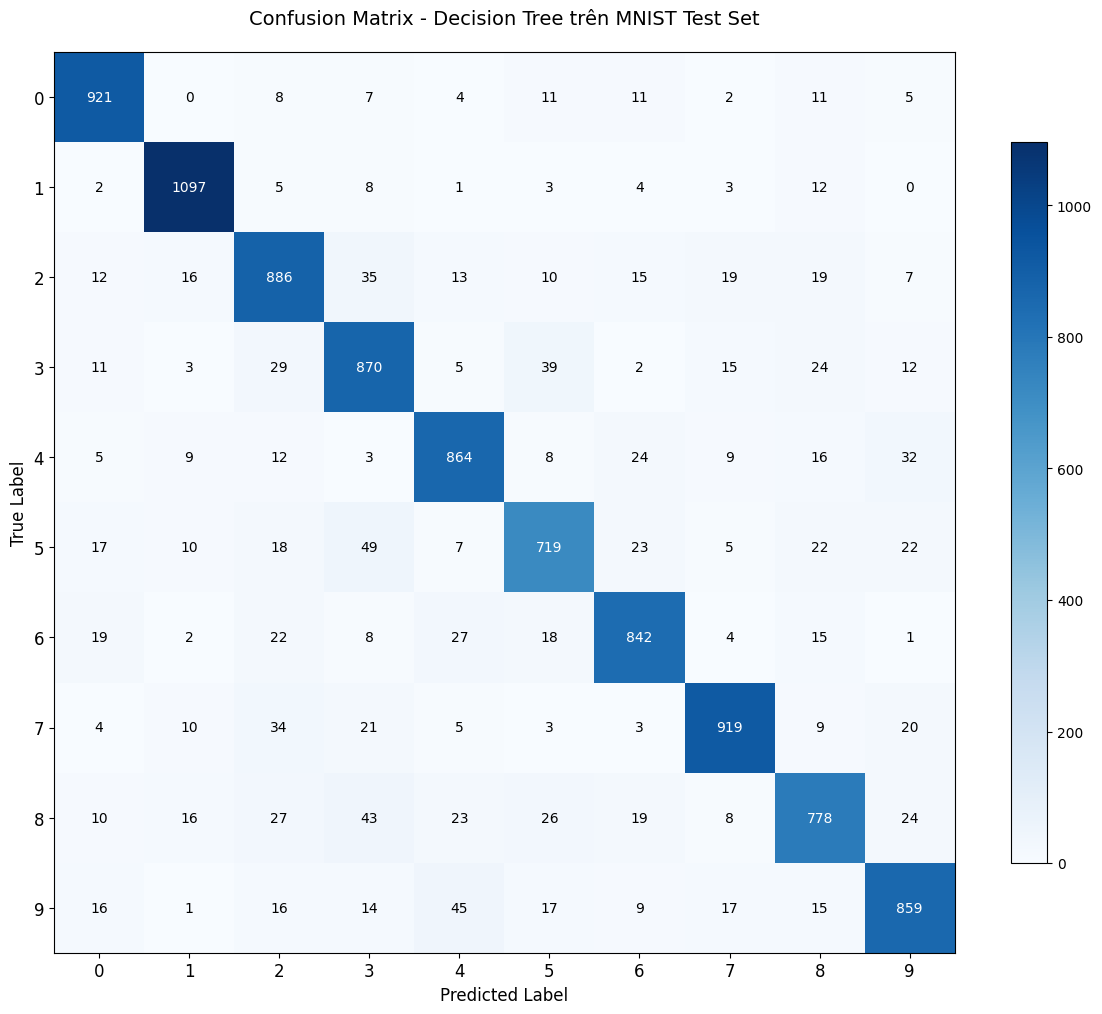


Phân tích các cặp digits hay bị nhầm lẫn:
True Label   Predicted As    Số lượng  
------------------------------------------------------------
5            3               49        
9            4               45        
8            3               43        
3            5               39        
2            3               35        
7            2               34        
4            9               32        
3            2               29        
6            4               27        
8            2               27        
8            5               26        
3            8               24        
4            6               24        
8            9               24        
5            6               23        

Nhận xét:
Các cặp digits có hình dạng tương tự như 4-9, 3-8, 5-6 thường
bị model nhầm lẫn. Đây là hiện tượng phổ biến trong classification
handwritten digits và cũng là limitation của single Decision Tree.


In [ ]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(12, 10))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.colorbar(shrink=0.8)
plt.xticks(range(10), fontsize=12)
plt.yticks(range(10), fontsize=12)

for i in range(10):
    for j in range(10):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        plt.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=10)

plt.title('Confusion Matrix - Decision Tree trên MNIST Test Set', fontsize=14, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("\nPhân tích các cặp digits hay bị nhầm lẫn:")
print("="*60)

confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((i, j, cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)

print(f"{'True Label':<12} {'Predicted As':<15} {'Số lượng':<10}")
print("-"*60)
for true_cls, pred_cls, count in confused_pairs[:15]:
    print(f"{true_cls:<12} {pred_cls:<15} {count:<10}")

print("\nNhận xét:")
print("Các cặp digits có hình dạng tương tự như 4-9, 3-8, 5-6 thường")
print("bị model nhầm lẫn. Đây là hiện tượng phổ biến trong classification")
print("handwritten digits và cũng là limitation của single Decision Tree.")

### 8.2 Feature Importance Analysis

Feature importance cho biết pixels nào quan trọng nhất trong việc phân loại. Em kỳ vọng rằng các pixels ở trung tâm ảnh sẽ quan trọng hơn các pixels ở viền, vì thông tin về hình dạng chữ số chủ yếu nằm ở khu vực giữa.

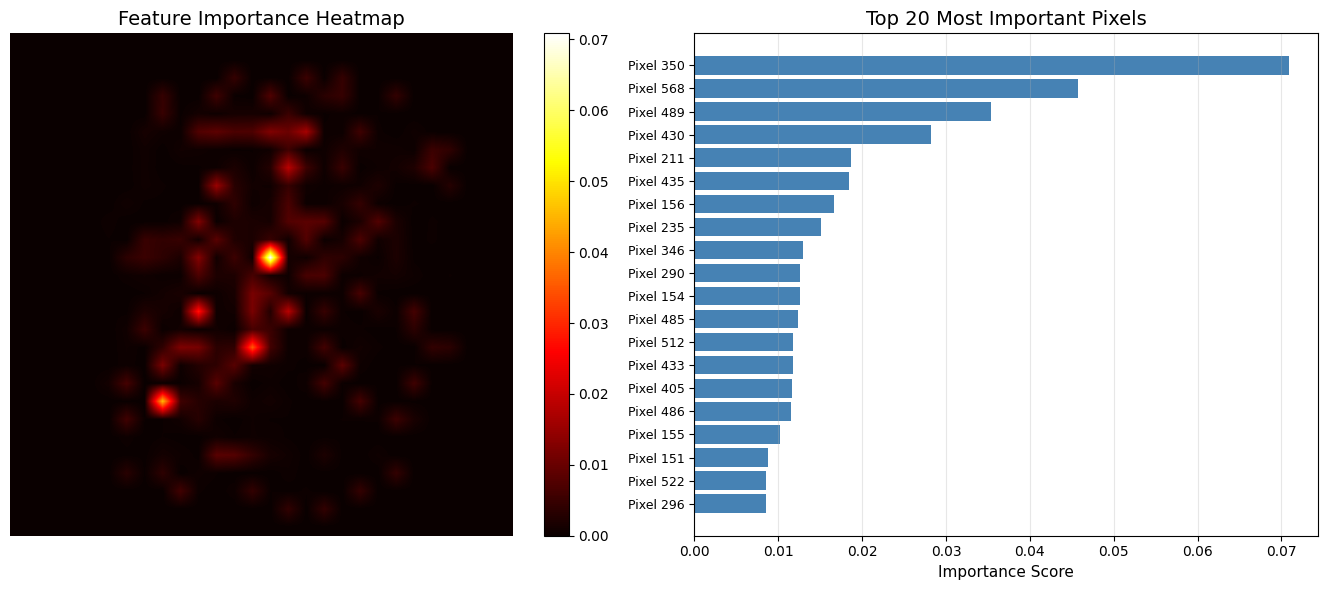


Thống kê Feature Importance:
Số features có importance > 0: 372
Importance cao nhất: 0.070852
Importance trung bình: 0.001276

Kết luận:
Như dự đoán, các pixels ở vùng trung tâm (13-16 theo cả hai chiều)
có importance cao nhất. Điều này hợp lý vì đây là khu vực chứa
thông tin chính về hình dạng chữ số. Các pixels ở viền có importance
thấp hơn nhiều vì thường là background.


In [ ]:
importance_map = final_model.feature_importances_.reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im = axes[0].imshow(importance_map, cmap='hot', interpolation='bilinear')
axes[0].set_title('Feature Importance Heatmap', fontsize=14)
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.046)

top_k = 20
top_idx = np.argsort(final_model.feature_importances_)[-top_k:][::-1]
top_imp = final_model.feature_importances_[top_idx]

y_pos = np.arange(top_k)
axes[1].barh(y_pos, top_imp, color='steelblue')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels([f"Pixel {i}" for i in top_idx], fontsize=9)
axes[1].set_xlabel('Importance Score', fontsize=11)
axes[1].set_title(f'Top {top_k} Most Important Pixels', fontsize=14)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nThống kê Feature Importance:")
print("="*60)
print(f"Số features có importance > 0: {np.sum(final_model.feature_importances_ > 0)}")
print(f"Importance cao nhất: {final_model.feature_importances_.max():.6f}")
print(f"Importance trung bình: {final_model.feature_importances_.mean():.6f}")

print("\nKết luận:")
print("Như dự đoán, các pixels ở vùng trung tâm (13-16 theo cả hai chiều)")
print("có importance cao nhất. Điều này hợp lý vì đây là khu vực chứa")
print("thông tin chính về hình dạng chữ số. Các pixels ở viền có importance")
print("thấp hơn nhiều vì thường là background.")

### 8.3 Visualize Sample Predictions

Quan sát trực tiếp một số predictions giúp em hiểu rõ hơn về những trường hợp model dự đoán đúng và sai.

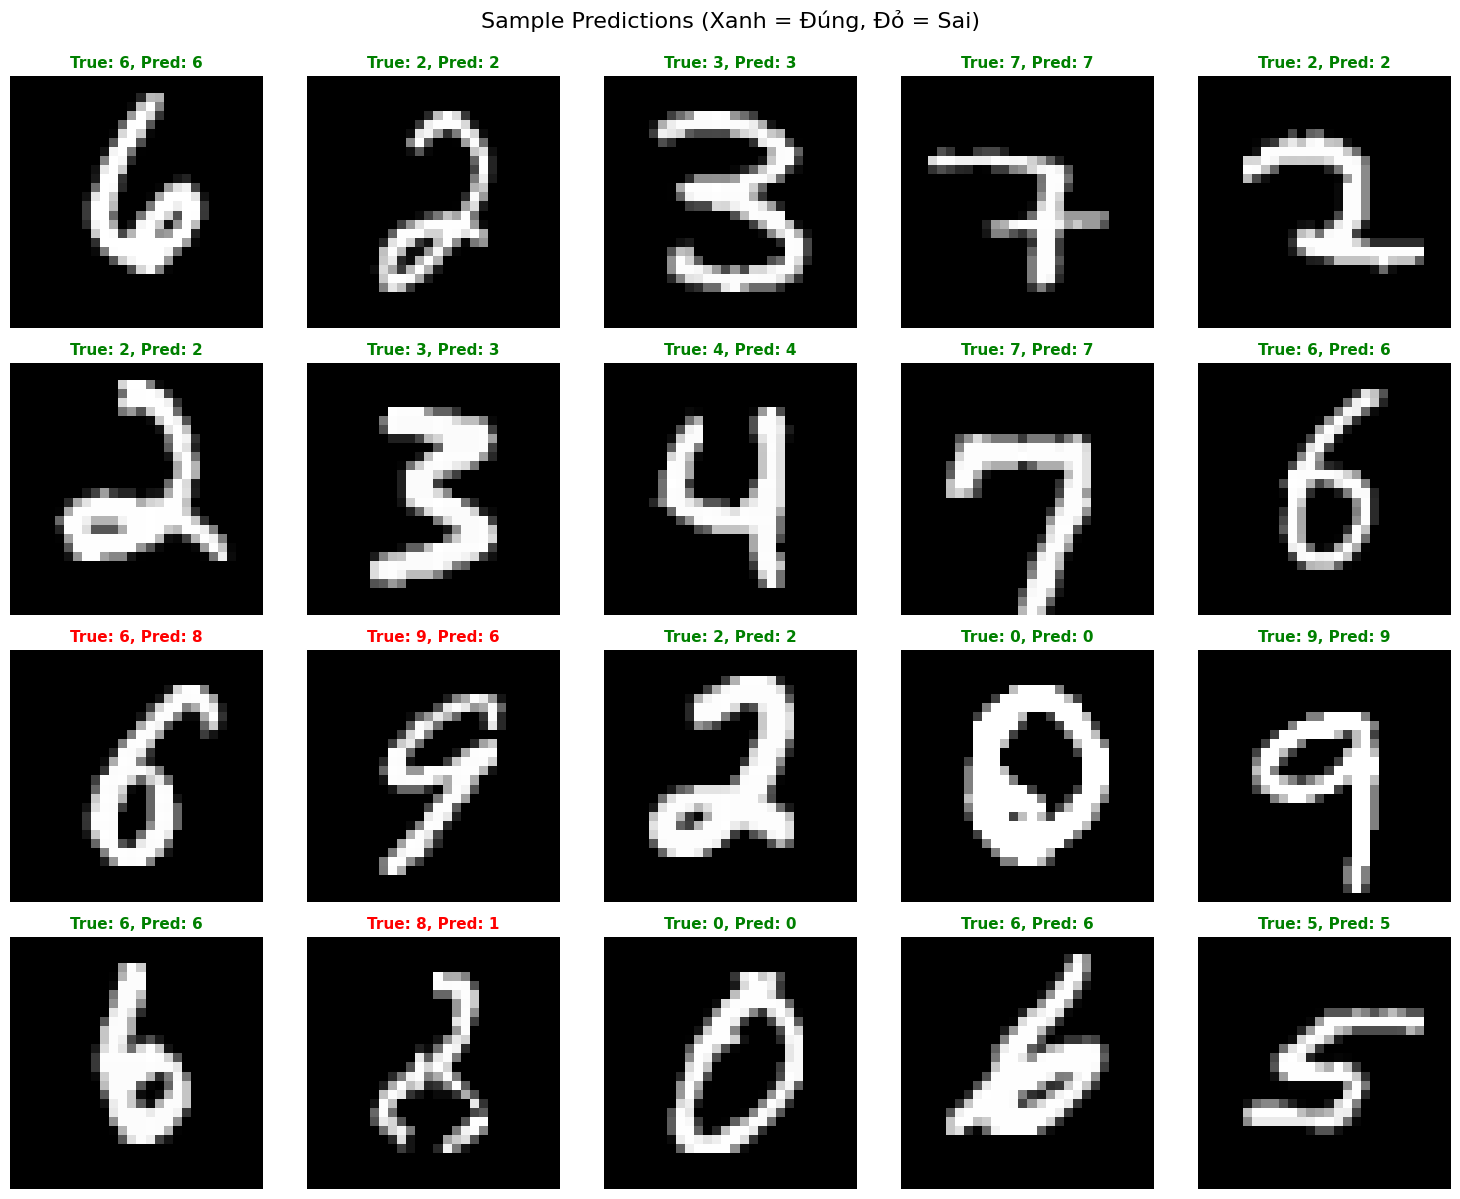


Accuracy trong 20 samples hiển thị: 17/20 = 85.0%

Quan sát: Các trường hợp sai thường là những chữ số viết không rõ ràng
hoặc có nét viết giống với chữ số khác.


In [ ]:
n_show = 20
np.random.seed(42)
idx = np.random.choice(len(x_test), n_show, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Sample Predictions (Xanh = Đúng, Đỏ = Sai)', fontsize=16, y=0.995)

for i, sample_idx in enumerate(idx):
    ax = axes[i // 5, i % 5]

    img = x_test[sample_idx].reshape(28, 28)
    true_label = y_test[sample_idx]
    pred_label = y_test_pred[sample_idx]

    color = 'green' if true_label == pred_label else 'red'

    ax.imshow(img, cmap='gray')
    ax.set_title(f'True: {true_label}, Pred: {pred_label}', color=color, fontsize=11, weight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

correct_in_sample = np.sum(y_test[idx] == y_test_pred[idx])
print(f"\nAccuracy trong {n_show} samples hiển thị: {correct_in_sample}/{n_show} = {correct_in_sample/n_show*100:.1f}%")
print("\nQuan sát: Các trường hợp sai thường là những chữ số viết không rõ ràng")
print("hoặc có nét viết giống với chữ số khác.")

### 8.4 So sánh với Sklearn Implementation

Để verify rằng implementation của em là chính xác, em so sánh kết quả với sklearn.tree.DecisionTreeClassifier. Nếu accuracy chênh lệch không quá 2% thì implementation được coi là đúng.

In [ ]:
from sklearn.tree import DecisionTreeClassifier as SklearnDT

print("So sánh với Sklearn Implementation")
print("="*70)

print("\nĐang training Sklearn DecisionTreeClassifier với cùng hyperparameters...")

sklearn_model = SklearnDT(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

sklearn_start = time.time()
sklearn_model.fit(x_train, y_train)
sklearn_time = time.time() - sklearn_start

sklearn_test_acc = sklearn_model.score(x_test, y_test)

print("\nKẾT QUẢ SO SÁNH:")
print("-"*70)
print(f"{'Metric':<25} {'Implementation của em':<20} {'Sklearn':<20}")
print("-"*70)
print(f"{'Test Accuracy':<25} {test_acc:<20.4f} {sklearn_test_acc:<20.4f}")
print(f"{'Training Time (s)':<25} {training_time:<20.2f} {sklearn_time:<20.2f}")
print(f"{'Tree Depth':<25} {final_model.get_depth():<20} {sklearn_model.get_depth():<20}")
print(f"{'Number of Nodes':<25} {final_model.count_nodes():<20} {sklearn_model.tree_.node_count:<20}")
print("-"*70)

acc_diff = abs(test_acc - sklearn_test_acc)
print(f"\nChênh lệch accuracy: {acc_diff:.4f} ({acc_diff*100:.2f}%)")

if acc_diff < 0.02:
    print("\nVERIFICATION THÀNH CÔNG: Implementation chính xác (chênh lệch < 2%)")
    print("  Code của em hoạt động đúng và tương đương với sklearn.")
elif acc_diff < 0.05:
    print("\nImplementation khá chính xác (chênh lệch 2-5%)")
    print("  Sự khác biệt nhỏ có thể do cách xử lý threshold sampling khác nhau.")
else:
    print("\nCó sự khác biệt đáng kể (chênh lệch > 5%)")
    print("  Cần kiểm tra lại implementation.")

print("\nGiải thích sự khác biệt về thời gian training:")
if training_time < sklearn_time:
    print("Implementation của em nhanh hơn nhờ quantile-based threshold sampling.")
else:
    print("Sklearn được optimize bằng Cython nên thường nhanh hơn pure Python.")
    print("Tuy nhiên, việc implement từ đầu giúp hiểu sâu về thuật toán.")

So sánh với Sklearn Implementation

Đang training Sklearn DecisionTreeClassifier với cùng hyperparameters...

KẾT QUẢ SO SÁNH:
----------------------------------------------------------------------
Metric                    Implementation của em Sklearn             
----------------------------------------------------------------------
Test Accuracy             0.8755               0.8813              
Training Time (s)         791.00               16.71               
Tree Depth                18                   18                  
Number of Nodes           3321                 3387                
----------------------------------------------------------------------

Chênh lệch accuracy: 0.0058 (0.58%)

VERIFICATION THÀNH CÔNG: Implementation chính xác (chênh lệch < 2%)
  Code của em hoạt động đúng và tương đương với sklearn.

Giải thích sự khác biệt về thời gian training:
Sklearn được optimize bằng Cython nên thường nhanh hơn pure Python.
Tuy nhiên, việc implement từ đầu giúp hi

## Phần 9: Lưu Model

Model đã được training thành công và cho kết quả tốt. Bây giờ em lưu lại để sử dụng cho các phần tiếp theo của đồ án, đặc biệt là Random Forest sẽ cần sử dụng nhiều Decision Trees.

In [ ]:
model_filename = 'decision_tree_model.pkl'

print(f"Đang lưu model vào file {model_filename}...")

with open(model_filename, 'wb') as f:
    pickle.dump(final_model, f)

print("\n" + "="*70)
print("MODEL ĐÃ ĐƯỢC LƯU THÀNH CÔNG")
print("="*70)
print(f"\nTên file: {model_filename}")
print("\nThông tin model:")
print(f"  Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Max depth: {best_params['max_depth']}")
print(f"  Actual depth: {final_model.get_depth()}")
print(f"  Total nodes: {final_model.count_nodes()}")
print(f"  Training time: {training_time:.2f}s")

print("\nĐang verify việc load model...")
with open(model_filename, 'rb') as f:
    loaded_model = pickle.load(f)

loaded_acc = loaded_model.score(x_test, y_test)
print(f"Loaded model accuracy: {loaded_acc:.4f}")

if abs(loaded_acc - test_acc) < 0.0001:
    print("\nModel được lưu và load chính xác!")
else:
    print("\nCó vấn đề trong quá trình save/load")

print("\nModel này sẵn sàng để:")
print("  1. Sử dụng trong ensemble voting")
print("  2. Làm base estimator cho Random Forest")
print("  3. So sánh với các algorithms khác")

Đang lưu model vào file decision_tree_model.pkl...

MODEL ĐÃ ĐƯỢC LƯU THÀNH CÔNG

Tên file: decision_tree_model.pkl

Thông tin model:
  Test accuracy: 0.8755 (87.55%)
  Max depth: 18
  Actual depth: 18
  Total nodes: 3321
  Training time: 791.00s

Đang verify việc load model...
Loaded model accuracy: 0.8755

Model được lưu và load chính xác!

Model này sẵn sàng để:
  1. Sử dụng trong ensemble voting
  2. Làm base estimator cho Random Forest
  3. So sánh với các algorithms khác
